<a href="https://colab.research.google.com/github/asdanomar15/Final_Project/blob/main/03_eda_shades.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA of Foundation Shades: Analyzing Lightness and Color Features

In this notebook, we perform Exploratory Data Analysis (EDA) to better understand the dataset after cleaning and feature engineering.

The goal of this analysis is to explore the distributions of key numerical features, examine relationships between variables, and identify patterns that may influence the target variable (L).

We use a variety of visualizations such as histograms, boxplots, scatter plots, and correlation heatmaps to gain insights into the data.

Additionally, grouping and aggregation techniques are applied to compare the target variable across different categories.

These insights will help guide further analysis and modeling steps.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/Shades_notebook3.csv')

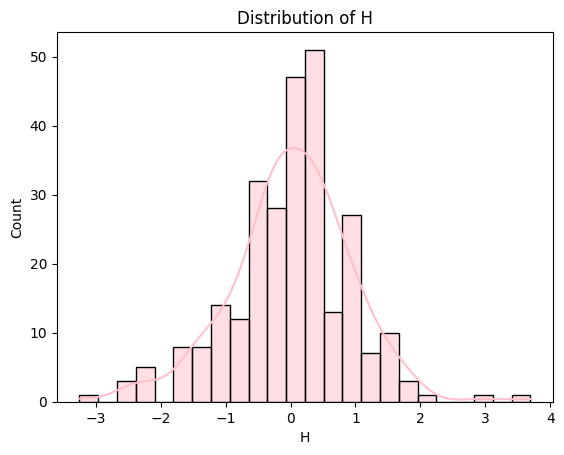

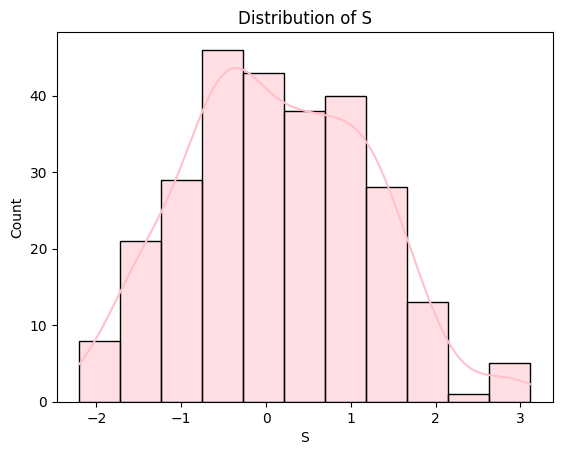

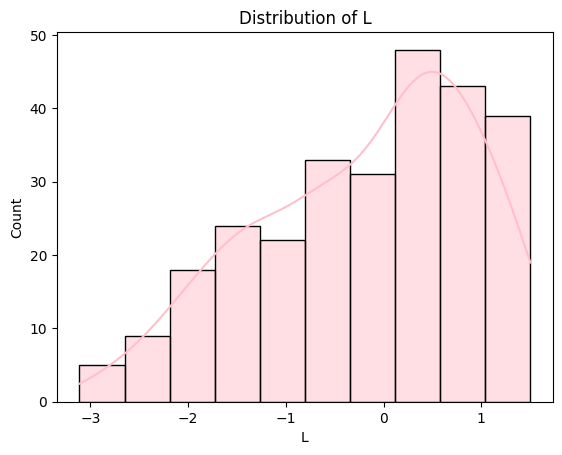

In [ ]:
cols = ['H','S','L']
for col in cols:
    sns.histplot(df[col],color='pink', kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

The distribution of L appears approximately symmetric, indicating a balanced spread of lightness values. In contrast, S shows slight positive skewness, meaning more values are concentrated at lower levels with a few higher values.

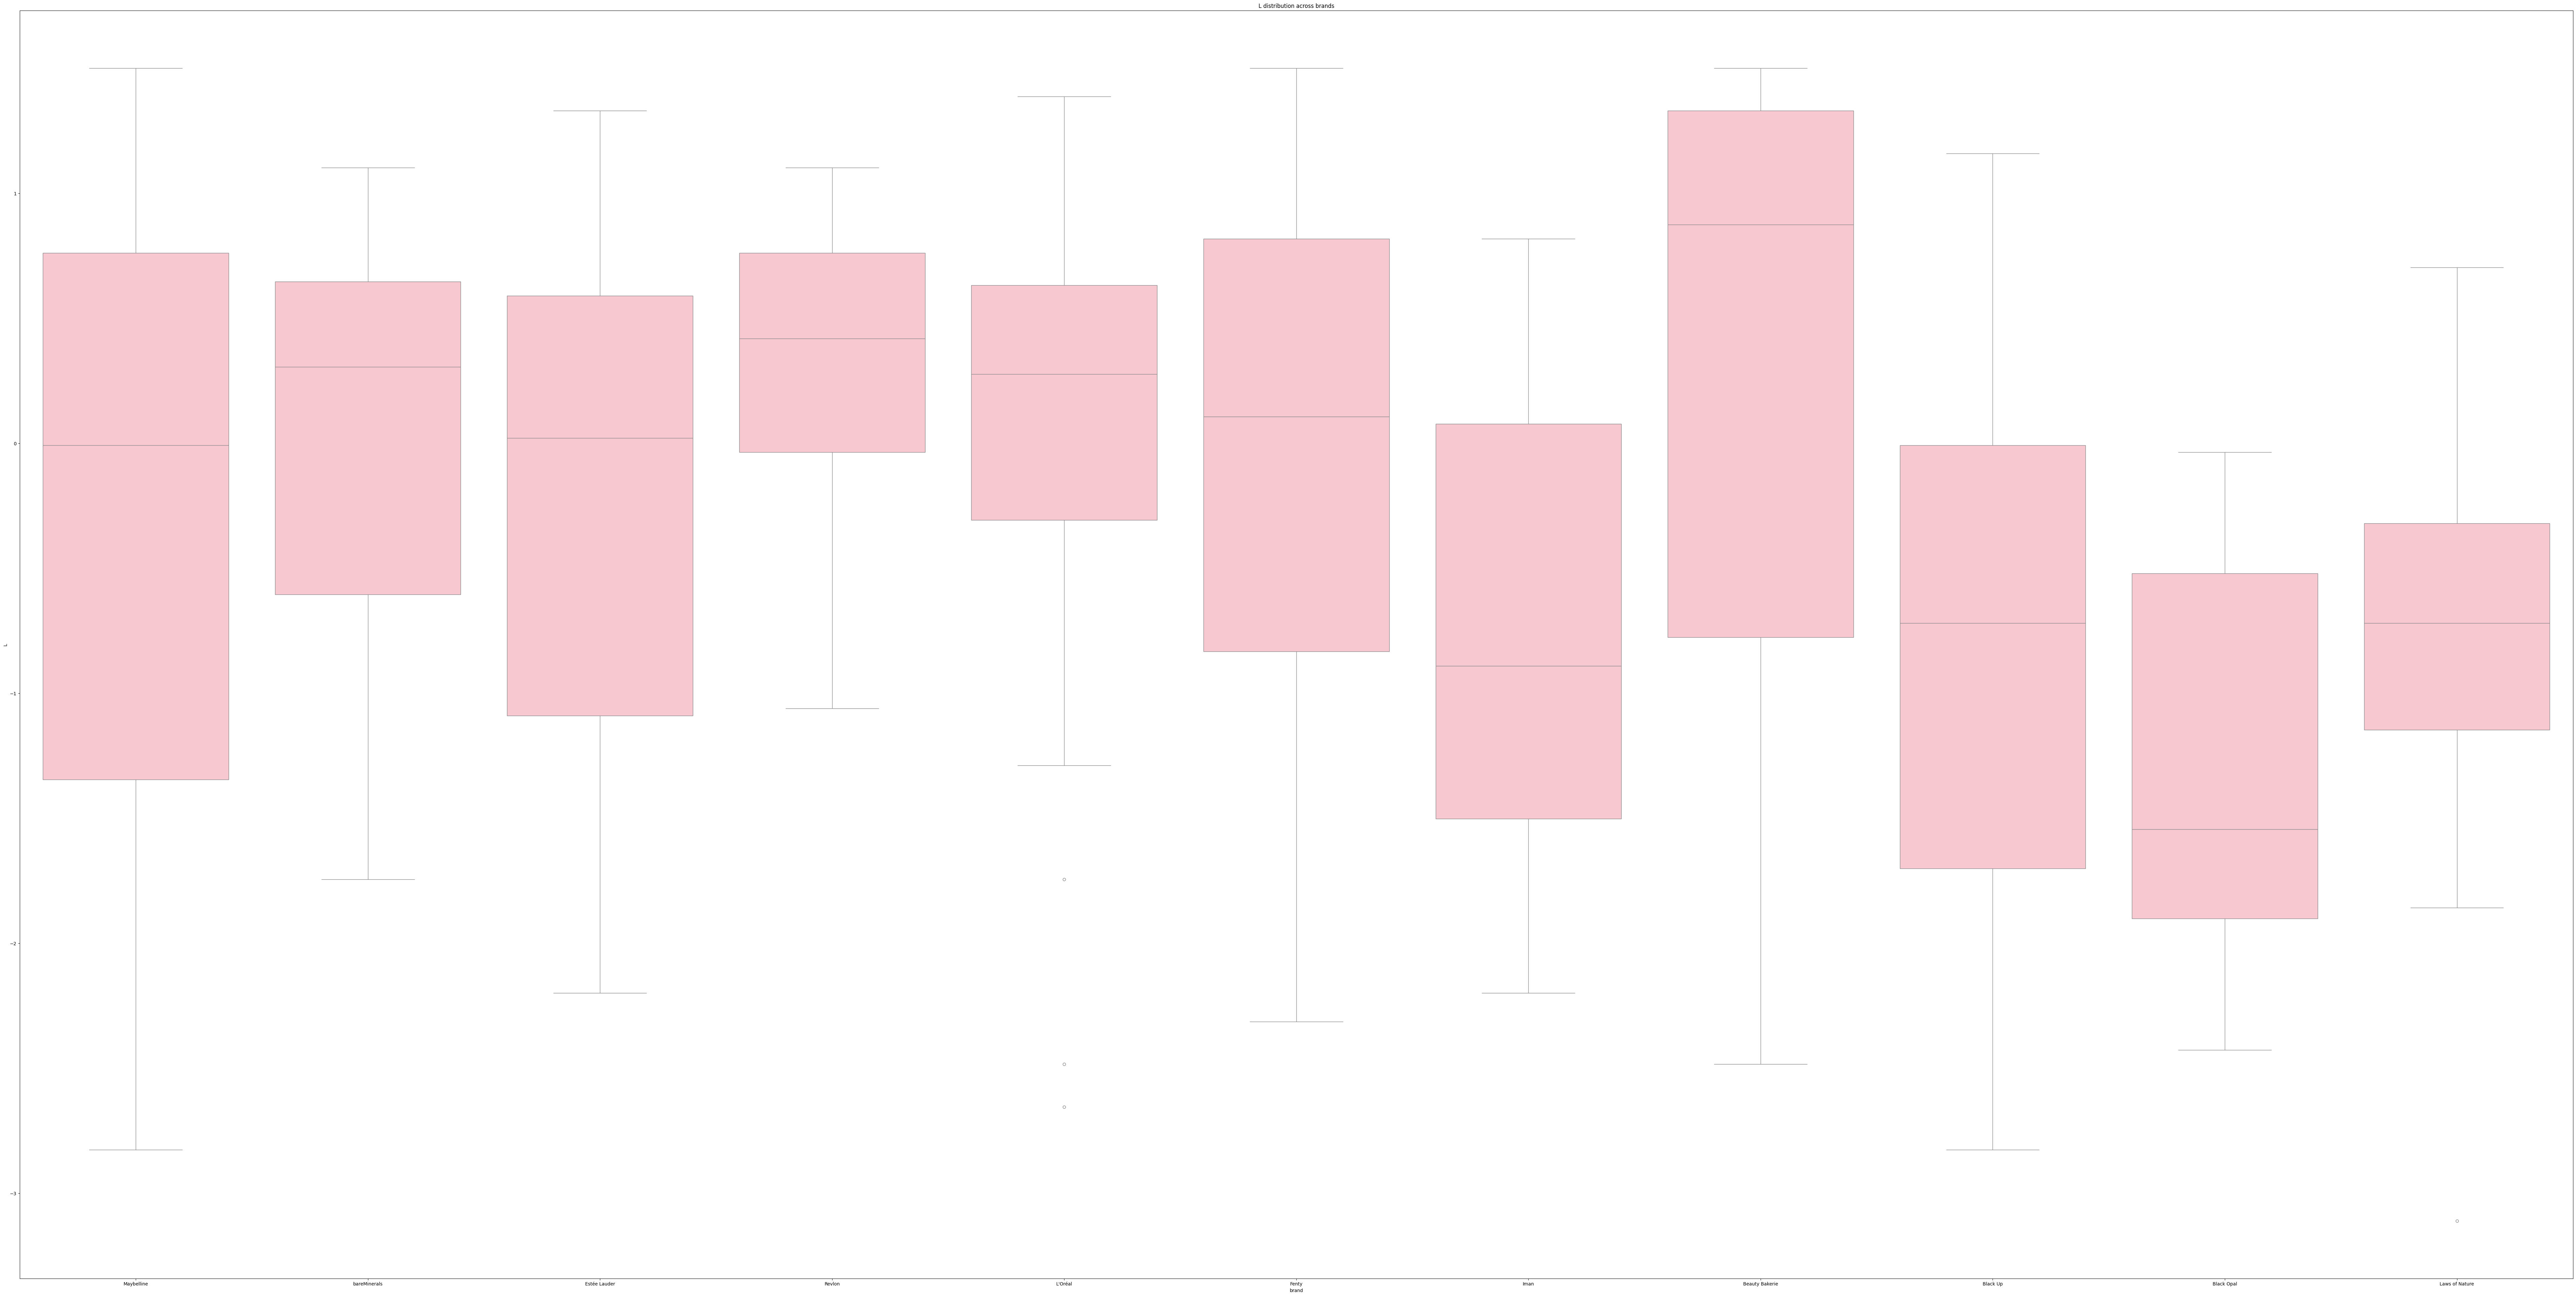

In [ ]:
plt.figure(figsize=(100,50))
sns.boxplot(x='brand', y='L',color='pink', data=df)
plt.title("L distribution across brands")
plt.show()

The boxplot shows clear variation in L across brands. Some brands have higher median lightness values, indicating they tend to produce lighter shades compared to others.

Text(0.5, 1.0, 'Top 10 Features Correlated with L')

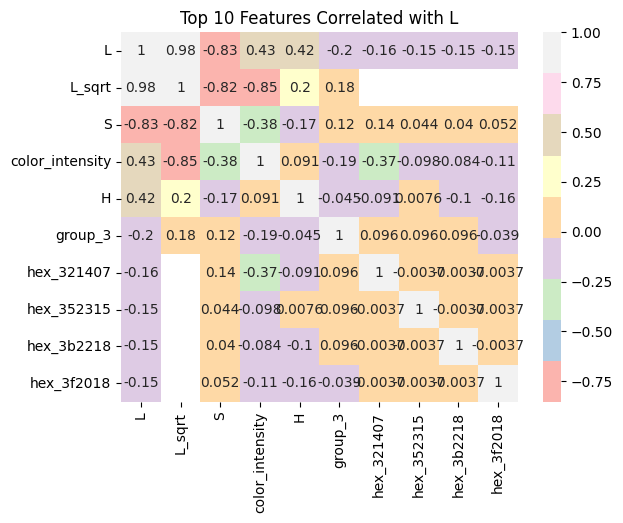

In [ ]:
corr = df.corr(numeric_only=True)['L'].abs().sort_values(ascending=False)
top_features = corr.head(10).index
sns.heatmap(df[top_features].corr(), annot=True, cmap='Pastel1')
plt.title("Top 10 Features Correlated with L")

The heatmap shows that L_sqrt has a very strong positive correlation with the target L (r = 0.98), as expected since it is a transformation of the same variable. Additionally, S has a strong negative correlation with L (-0.81), indicating that higher saturation is associated with lower lightness.

Color_intensity also shows a moderate positive relationship with L (0.39), while H has a moderate correlation (0.45). Other features, including group variables and hex encoding, show weak correlations, suggesting they have a limited direct impact on the target.

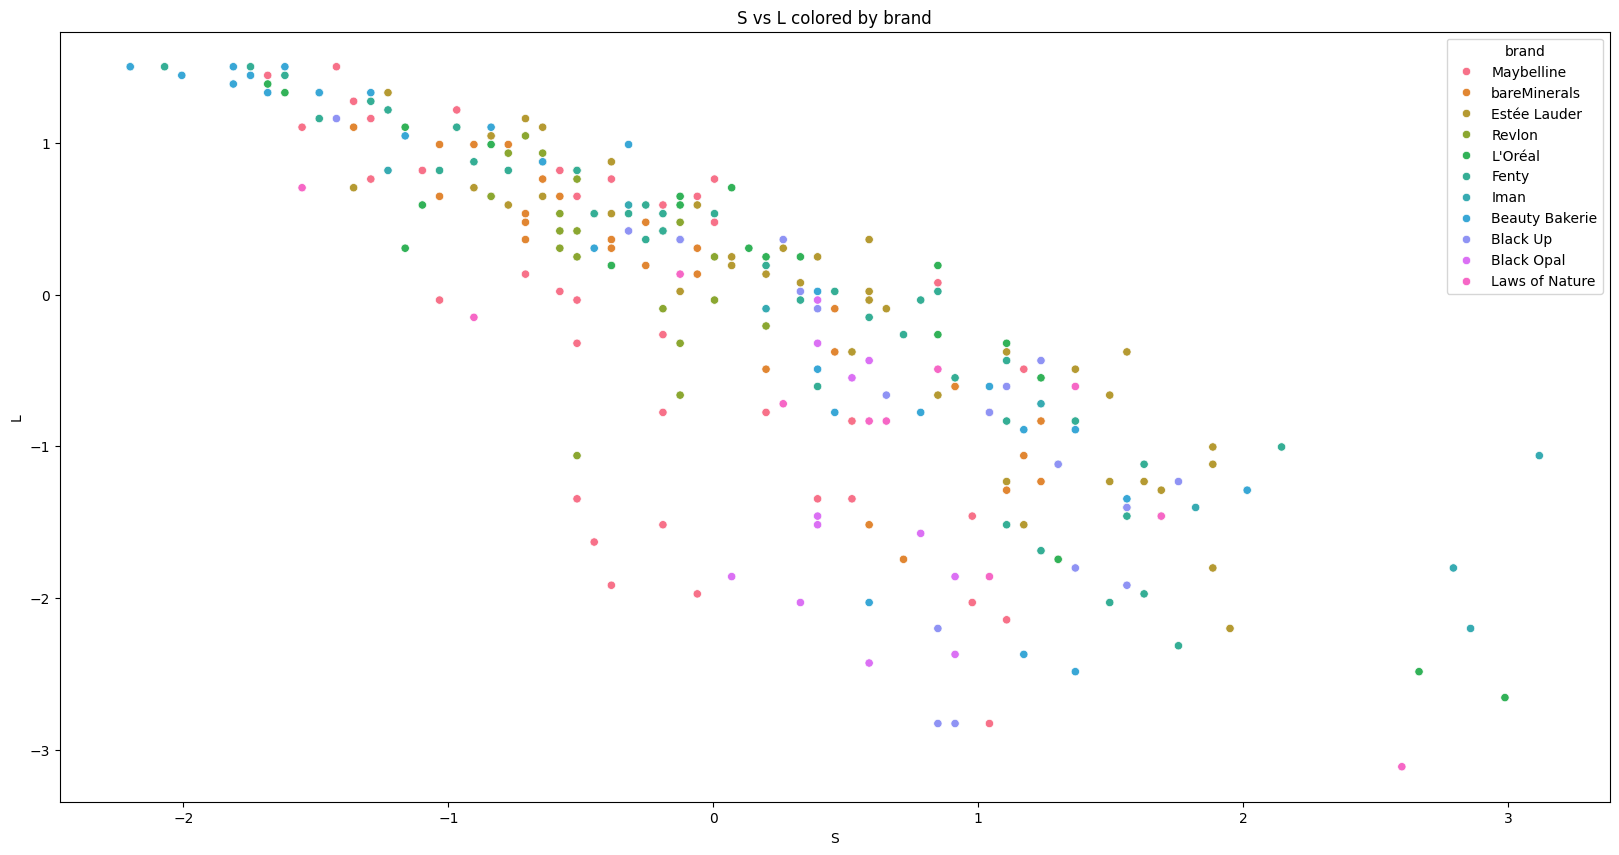

In [ ]:
plt.figure(figsize=(20,10))
sns.scatterplot(x='S', y='L', hue='brand', data=df,)
plt.title("S vs L colored by brand")
plt.show()

The scatter plot shows a negative relationship between S and L, where higher saturation corresponds to lower lightness. The color grouping reveals variation across brands.

In [ ]:
group_mean = df.groupby('brand')['L'].mean().sort_values()
print(group_mean)

brand
Black Opal       -1.369523
Black Up         -0.865008
Laws of Nature   -0.838553
Iman             -0.733739
Maybelline       -0.219893
Estée Lauder     -0.184037
Fenty            -0.004960
L'Oréal           0.002545
bareMinerals      0.034405
Beauty Bakerie    0.213065
Revlon            0.329742
Name: L, dtype: float64


The groupby analysis shows clear differences in average L values across brands. Brands such as Black Opal and House of Tara have the lowest mean values, indicating darker shades, while brands like IPSA, Dior, and RMK have the highest mean values, representing lighter shades. This highlights variation in shade offerings across brands.

In [ ]:
df.to_csv("shades_notebook4", index=False)